## Preprocess DEAP

In [2]:
# imports
import mne
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# data & processing
eeg = mne.io.read_raw_bdf('data/DEAP/s09.bdf')
events = mne.find_events(eeg, stim_channel='Status', shortest_event=1, initial_event=True)

Extracting EDF parameters from /Users/yeganeh/Codes/EEGModalNet/data/DEAP/s09.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Finding events on: Status
289 events found on stim channel Status
Event IDs: [    1     2     3     4     5     7 65536]


### Decode event ids

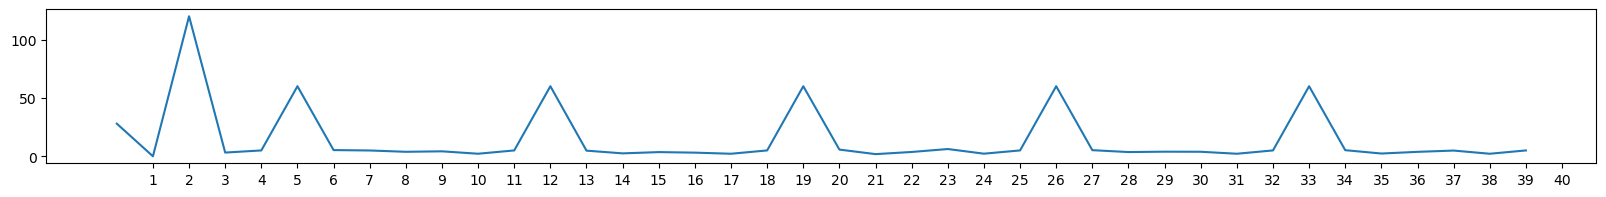

In [4]:
# Convert sample numbers to seconds
event_times = events[:, 0] / eeg.info['sfreq']
diff_arr = np.diff(event_times)
event_id_occurance = np.unique(events[:, 2], return_counts=True)
plt.figure(figsize=(20, 2))
l = 40
plt.plot(diff_arr[:l])
plt.xticks(np.arange(1, l+1))
plt.show()

In [5]:
# the number of occurance of each trigger id and the interval between them tell us what each corresponds to:
event_id = {'baseline_start': 3,
            'video_start': 4,
            'video_end': 5}

epochs = mne.Epochs(eeg,
                    events,
                    event_id=event_id['video_start'],  # only need the video start point to epoch the data
                    tmin=0,
                    tmax=60,
                    baseline=None)

Not setting metadata
40 matching events found
No baseline correction applied
0 projection items activated
